# Module 2 — Emotion Classifier
This notebook covers all stages of the emotion classification pipeline:
1. **EDA & Preprocessing** — Load, clean, and explore the dataset
2. **Baseline Model** — TF-IDF + Logistic Regression
3. **DistilBERT Training** — Fine-tune a transformer model
4. **Evaluation** — Test the trained DistilBERT model

---
## 0. Setup

In [1]:
# Install dependencies (Colab)
!pip install -q transformers datasets scikit-learn pandas matplotlib seaborn

In [2]:
# Mount Google Drive to persist outputs & model across sessions
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path

# All outputs saved to Drive so they survive session disconnect
DRIVE_ROOT  = Path('/content/drive/MyDrive/emotion_classifier')

DATA_DIR    = DRIVE_ROOT / 'data'
OUTPUT_DIR  = DRIVE_ROOT / 'outputs'
MODEL_DIR   = DRIVE_ROOT / 'models'
BERT_DIR    = MODEL_DIR  / 'distilbert'

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
BERT_DIR.mkdir(parents=True, exist_ok=True)

print('Data      ->', DATA_DIR)
print('Outputs   ->', OUTPUT_DIR)
print('Models    ->', MODEL_DIR)

Data      -> /content/drive/MyDrive/emotion_classifier/data
Outputs   -> /content/drive/MyDrive/emotion_classifier/outputs
Models    -> /content/drive/MyDrive/emotion_classifier/models


---
## 1. EDA & Preprocessing

In [4]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [5]:
# Loading dataset
dataset = load_dataset('dair-ai/emotion')
label_names = dataset['train'].features['label'].names
# the 6 classes --> ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Change dataset to dataframe and add emotion labels and text length
def to_df(split):
    df = pd.DataFrame(dataset[split])
    df.columns = ['text', 'label']
    df['emotion'] = df['label'].map(lambda x: label_names[x])
    df['length']  = df['text'].apply(lambda x: len(x.split()))
    return df

df_train = to_df('train')
df_val   = to_df('validation')
df_test  = to_df('test')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [6]:
def preprocess(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    original_len = len(df)

    # Drop duplicates
    df = df.drop_duplicates(subset=['text', 'label'])
    dupes_dropped = original_len - len(df)

    # Drop null/empty texts
    df = df[df['text'].notna()]
    df = df[df['text'].str.strip() != '']

    # Strip HTML artifacts
    df['text'] = df['text'].str.replace(r'<[^>]+>', '', regex=True)
    df['text'] = df['text'].str.replace(r'img\s+src\s+\S+', '', regex=True)
    df['text'] = df['text'].str.replace(r'http\S+', '', regex=True)

    # Normalize whitespace
    df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

    # Remove rows that became empty after cleaning
    df = df[df['text'].str.strip() != '']

    # Drop extreme-length outliers (too short: <= 2 words, too long: > 300 words)
    df['length'] = df['text'].apply(lambda x: len(x.split()))
    before_len_filter = len(df)
    df = df[(df['length'] >= 3) & (df['length'] <= 300)]
    length_dropped = before_len_filter - len(df)

    print(f'\n=== Preprocessing — {split_name} ===')
    print(f'  Original rows          : {original_len}')
    print(f'  Duplicates dropped     : {dupes_dropped}')
    print(f'  Length outliers dropped: {length_dropped}')
    print(f'  Final rows             : {len(df)}')

    return df.reset_index(drop=True)

df_train = preprocess(df_train, 'train')
df_val   = preprocess(df_val,   'validation')
df_test  = preprocess(df_test,  'test')


=== Preprocessing — train ===
  Original rows          : 16000
  Duplicates dropped     : 1
  Length outliers dropped: 8
  Final rows             : 15991

=== Preprocessing — validation ===
  Original rows          : 2000
  Duplicates dropped     : 0
  Length outliers dropped: 1
  Final rows             : 1999

=== Preprocessing — test ===
  Original rows          : 2000
  Duplicates dropped     : 0
  Length outliers dropped: 0
  Final rows             : 2000


In [7]:
# Save cleaned data to Drive
df_train.to_parquet(DATA_DIR / 'train.parquet', index=False)
df_val.to_parquet(DATA_DIR   / 'val.parquet',   index=False)
df_test.to_parquet(DATA_DIR  / 'test.parquet',  index=False)
print('Saved cleaned data to Drive successfully')

Saved cleaned data to Drive successfully



=== Class Distribution (train) ===
emotion
joy         5359
sadness     4665
anger       2156
fear        1935
love        1304
surprise     572
Name: count, dtype: int64


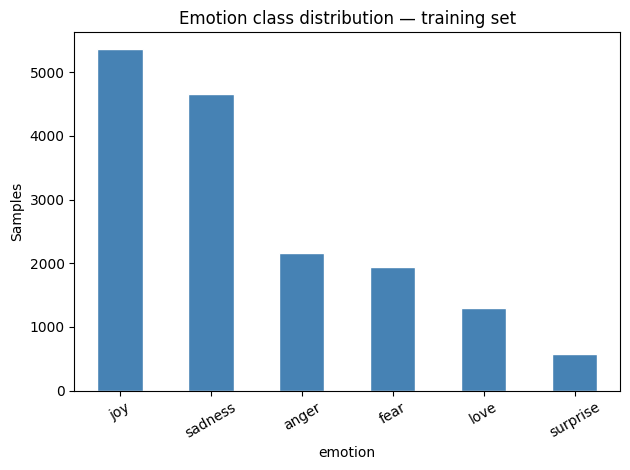

Saved -> class_distribution.png


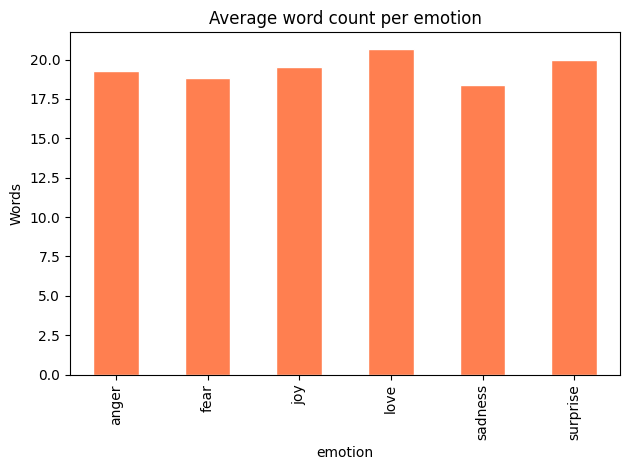

Saved -> length_per_emotion.png

=== Sample texts per emotion ===

--- SADNESS ---
  • im feeling so lousy they tried to cheer me up during school time and during choir practice
  • i feel highly disadvantaged
  • i feel humiliated to introduce you to my colleagues as my wife

--- JOY ---
  • i hate missing practice because i feel like the reps in practice are vital to your performance on sunday
  • i feel very triumphant another personal mini goal accomplished
  • im even starting to feel more sociable

--- LOVE ---
  • i mean fuck i feel like i was way more considerate with customers and concerned about appearance and sanitiation snoozel pm but fine
  • i remember a couple of years ago i was feeling romantic and dreamy and asked him wonder if we ll celebrate our th anniversary
  • im so going to end up feeling slutty and be like ah

--- ANGER ---
  • i feel like im presenting myself in a less hostile manner now when i am dragged to an event or gathering full of stupid fake people
  •

In [8]:
# Class distribution
print('\n=== Class Distribution (train) ===')
print(df_train['emotion'].value_counts())

df_train['emotion'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Emotion class distribution — training set')
plt.ylabel('Samples')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png')
plt.show()
print('Saved -> class_distribution.png')

# Average text length per emotion
df_train.groupby('emotion')['length'].mean().plot(kind='bar', color='coral', edgecolor='white')
plt.title('Average word count per emotion')
plt.ylabel('Words')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'length_per_emotion.png')
plt.show()
print('Saved -> length_per_emotion.png')

# Sample texts per emotion
print('\n=== Sample texts per emotion ===')
for emotion in label_names:
    print(f'\n--- {emotion.upper()} ---')
    samples = df_train[df_train['emotion'] == emotion]['text'].sample(3, random_state=42)
    for s in samples:
        print(f'  • {s}')

---
## 2. Baseline Model — TF-IDF + Logistic Regression

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import pickle

In [10]:
label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
df_train = pd.read_parquet(DATA_DIR / 'train.parquet')
df_val   = pd.read_parquet(DATA_DIR / 'val.parquet')

# TF-IDF + Logistic Regression
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(df_train['text'])
X_val   = vectorizer.transform(df_val['text'])

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, df_train['label'])

preds  = clf.predict(X_val)
report = classification_report(df_val['label'], preds, target_names=label_names)
print('\n=== Baseline Report (TF-IDF + LogReg) ===')
print(report)

with open(OUTPUT_DIR / 'baseline_report.txt', 'w') as f:
    f.write(report)

# Save model
pickle.dump({'vectorizer': vectorizer, 'clf': clf}, open(MODEL_DIR / 'baseline.pkl', 'wb'))
print('Saved -> baseline_report.txt')
print('Saved -> models/baseline.pkl')


=== Baseline Report (TF-IDF + LogReg) ===
              precision    recall  f1-score   support

     sadness       0.92      0.89      0.90       550
         joy       0.93      0.88      0.90       704
        love       0.75      0.95      0.84       178
       anger       0.88      0.89      0.89       275
        fear       0.82      0.82      0.82       211
    surprise       0.71      0.80      0.76        81

    accuracy                           0.88      1999
   macro avg       0.83      0.87      0.85      1999
weighted avg       0.88      0.88      0.88      1999

Saved -> baseline_report.txt
Saved -> models/baseline.pkl


---
## 3. DistilBERT Fine-Tuning

In [11]:
import numpy as np
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from sklearn.metrics import f1_score

In [12]:
label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
num_labels  = len(label_names)

df_train = pd.read_parquet(DATA_DIR / 'train.parquet')
df_val   = pd.read_parquet(DATA_DIR / 'val.parquet')

hf_dataset = DatasetDict({
    'train':      Dataset.from_pandas(df_train[['text', 'label']]),
    'validation': Dataset.from_pandas(df_val[['text', 'label']]),
})

print(f'Labels: {label_names}')
print(f'Training samples: {len(hf_dataset["train"])}')

# Training configuration
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS     = 5
LR         = 2e-5

Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Training samples: 15991


In [13]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH, padding=False)

tokenized = hf_dataset.map(tokenize, batched=True)
tokenized = tokenized.rename_column('label', 'labels')
tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

Map:   0%|          | 0/15991 [00:00<?, ? examples/s]

Map:   0%|          | 0/1999 [00:00<?, ? examples/s]

In [14]:
# Class weights to handle imbalance
label_counts  = np.bincount(hf_dataset['train']['label'])
class_weights = torch.tensor(1.0 / label_counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * num_labels

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
class_weights = class_weights.to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

Using device: cuda


In [15]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label={i: l for i, l in enumerate(label_names)},
    label2id={l: i for i, l in enumerate(label_names)},
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'f1': f1_score(labels, preds, average='macro')}

args = TrainingArguments(
    output_dir=str(BERT_DIR),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_dir=str(OUTPUT_DIR / 'logs'),
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to='none',
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print('\nStarting training...')
trainer.train()

model.save_pretrained(str(BERT_DIR))
tokenizer.save_pretrained(str(BERT_DIR))
print(f'\nModel saved -> {BERT_DIR}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Starting training...


Epoch,Training Loss,Validation Loss,F1
1,0.283869,0.234201,0.888905
2,0.182977,0.176592,0.913345
3,0.139133,0.190144,0.906712
4,0.091361,0.167902,0.918592
5,0.081178,0.185854,0.914552


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved -> /content/drive/MyDrive/emotion_classifier/models/distilbert


---
## 4. Evaluation — DistilBERT on Validation Set

In [17]:
from sklearn.metrics import classification_report

MAX_LENGTH = 128

eval_dataset = load_dataset('dair-ai/emotion')
label_names  = eval_dataset['train'].features['label'].names

tokenizer = AutoTokenizer.from_pretrained(str(BERT_DIR))

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH, padding=False)

tokenized_eval = eval_dataset['validation'].map(tokenize, batched=True)
tokenized_eval = tokenized_eval.rename_column('label', 'labels')
tokenized_eval.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

model = AutoModelForSequenceClassification.from_pretrained(str(BERT_DIR))

eval_trainer = Trainer(
    model=model,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
)

predictions = eval_trainer.predict(tokenized_eval)
preds  = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

report = classification_report(labels, preds, target_names=label_names)
print('\n=== DistilBERT Classification Report ===')
print(report)

with open(OUTPUT_DIR / 'distilbert_report.txt', 'w') as f:
    f.write(report)
print('Saved -> distilbert_report.txt')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== DistilBERT Classification Report ===
              precision    recall  f1-score   support

     sadness       0.98      0.95      0.97       550
         joy       0.99      0.93      0.96       704
        love       0.81      0.95      0.88       178
       anger       0.94      0.95      0.95       275
        fear       0.88      0.92      0.90       212
    surprise       0.79      0.95      0.87        81

    accuracy                           0.94      2000
   macro avg       0.90      0.94      0.92      2000
weighted avg       0.94      0.94      0.94      2000

Saved -> distilbert_report.txt
